# 01. 데이터셋 준비
- shard_0 폴더 구조 확인
- Dataset / DataLoader 클래스 정의
- Train / Val / Test 분할 (8:1:1)
- 샘플 이미지 시각화

In [8]:
# ============================================================
# 경로 설정 — 본인 환경에 맞게 수정
# ============================================================
# shard_0.zip 압축 해제 후 아래 경로에 shard_0 폴더가 있어야 함
# 예시: data/train/shard_0/images/ + data/train/shard_0/labels.csv
SHARD_ROOT = "../data/train"   # shard_0 이 들어있는 상위 폴더

In [9]:
# ============================================================
# 데이터 구조 확인
# ============================================================
import os
import pandas as pd
from pathlib import Path

shard_path = os.path.join(SHARD_ROOT, "shard_0")
labels_df  = pd.read_csv(os.path.join(shard_path, "labels.csv"), index_col=0)

print(f"총 이미지 수 : {len(labels_df)}")
print(f"\n클래스 분포:")
print(labels_df["label"].value_counts().rename({0: "Real", 1: "AI Generated"}))
print(f"\n샘플 데이터:")
print(labels_df.head())

총 이미지 수 : 50000

클래스 분포:
label
AI Generated    32018
Real            17982
Name: count, dtype: int64

샘플 데이터:
                 image_name  label
0  ed97447bcc3cea21bfa2.jpg      0
1  8252d6ad09a67674576a.jpg      0
2  01a84d7398e97a047b7c.jpg      1
3  0c6a4e6cca4e9e582cf9.jpg      1
4  99aec474f7ef493820c9.jpg      1


C:\Users\Sin\AppData\Local\Temp\ipykernel_25752\2230733724.py:19: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Sin\AppData\Local\Temp\ipykernel_25752\2230733724.py:19: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Sin\AppData\Local\Temp\ipykernel_25752\2230733724.py:19: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Sin\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Sin\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Sin\AppData\Local\Pro

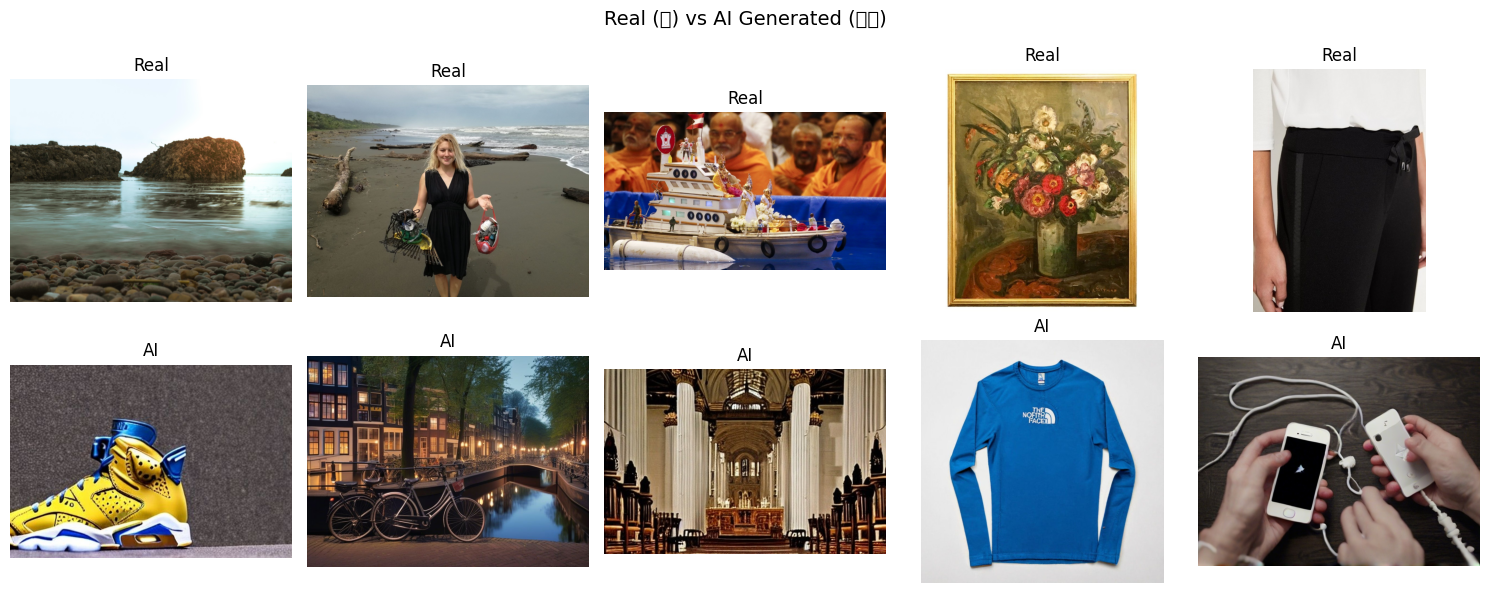

In [10]:
# ============================================================
# 샘플 이미지 시각화 (Real 5장 / AI 5장)
# ============================================================
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Real (위) vs AI Generated (아래)", fontsize=14)

for row_idx, label in enumerate([0, 1]):
    samples = labels_df[labels_df["label"] == label].head(5)
    for col_idx, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(shard_path, "images", row["image_name"])
        img = Image.open(img_path).convert("RGB")
        axes[row_idx][col_idx].imshow(img)
        axes[row_idx][col_idx].axis("off")
        axes[row_idx][col_idx].set_title("Real" if label == 0 else "AI")

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# Dataset 클래스 정의
# ============================================================
import torch
from torch.utils.data import Dataset
from torchvision import transforms

class AIGenDetDataset(Dataset):
    """
    NTIRE 2026 Train Dataset (shard 구조)
    label: 0 = Real, 1 = AI Generated
    """
    def __init__(self, shard_dir: str, shard_nums=None, transform=None, max_samples: int = None):
        self.shard_root = shard_dir
        self.transform  = transform

        if shard_nums is None:
            shard_dirs = [os.path.join(shard_dir, f"shard_{i}") for i in range(6)]
        else:
            shard_dirs = [os.path.join(shard_dir, f"shard_{i}") for i in shard_nums]

        shard_dirs = [x for x in shard_dirs if os.path.isdir(x)]

        dfs = []
        for sp in shard_dirs:
            df = pd.read_csv(os.path.join(sp, "labels.csv"), index_col=0)
            df["shard_name"] = Path(sp).name
            dfs.append(df)

        self.label_df = pd.concat(dfs, ignore_index=True)

        # max_samples 지정 시 Real/AI 균형 맞춰서 샘플링
        if max_samples is not None:
            n_each   = max_samples // 2
            real_df  = self.label_df[self.label_df["label"] == 0].sample(
                n=min(n_each, (self.label_df["label"]==0).sum()), random_state=42
            )
            fake_df  = self.label_df[self.label_df["label"] == 1].sample(
                n=min(n_each, (self.label_df["label"]==1).sum()), random_state=42
            )
            self.label_df = pd.concat([real_df, fake_df]).sample(
                frac=1, random_state=42
            ).reset_index(drop=True)

        print(f"사용 shards: {len(shard_dirs)}개, 총 이미지: {len(self.label_df):,}장 "
              f"(Real: {(self.label_df['label']==0).sum():,} / AI: {(self.label_df['label']==1).sum():,})")

    def __len__(self):
        return len(self.label_df)

    def __getitem__(self, idx):
        row      = self.label_df.iloc[idx]
        img_path = os.path.join(self.shard_root, row["shard_name"], "images", row["image_name"])
        image    = Image.open(img_path).convert("RGB")
        label    = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [16]:
# ============================================================
# Transform 정의 (Train 증강 / Val·Test 정규화만)
# ============================================================
# ImageNet pretrained ResNet 기준 정규화값
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),           # 좌우 반전
    transforms.RandomVerticalFlip(p=0.2),             # 상하 반전
    transforms.RandomRotation(degrees=15),            # 최대 15도 회전
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3,
        saturation=0.2, hue=0.1
    ),                                                # 색상 증강
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

In [17]:
# ============================================================
# Train / Val / Test 분할 (8:1:1)
# ============================================================
from torch.utils.data import DataLoader, random_split

MAX_SAMPLES = 10000
full_dataset = AIGenDetDataset(
    shard_dir   = SHARD_ROOT,
    shard_nums  = [0],
    transform   = train_transform,
    max_samples = MAX_SAMPLES    # ← 이게 있어야 함
)

total      = len(full_dataset)
train_size = int(0.8 * total)
val_size   = int(0.1 * total)
test_size  = total - train_size - val_size

# manual_seed로 재현성 보장
generator = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = random_split(
    full_dataset, [train_size, val_size, test_size], generator=generator
)

# Val / Test 에는 증강 없이 정규화만 적용
val_ds.dataset.transform  = val_transform
test_ds.dataset.transform = val_transform

print(f"Train: {len(train_ds)}장")
print(f"Val  : {len(val_ds)}장")
print(f"Test : {len(test_ds)}장")

사용 shards: 1개, 총 이미지: 10,000장 (Real: 5,000 / AI: 5,000)
Train: 8000장
Val  : 1000장
Test : 1000장


In [18]:
# ============================================================
# DataLoader 생성 및 배치 shape 확인
# ============================================================
BATCH_SIZE = 64


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

# 배치 하나 꺼내서 shape 확인
imgs, labels = next(iter(train_loader))
print(f"이미지 배치 shape: {imgs.shape}")   # (32, 3, 224, 224)
print(f"라벨 배치 shape : {labels.shape}")  # (32,)
print(f"라벨 예시       : {labels[:10]}")

이미지 배치 shape: torch.Size([64, 3, 224, 224])
라벨 배치 shape : torch.Size([64])
라벨 예시       : tensor([0, 1, 1, 1, 1, 0, 1, 1, 0, 1])
